In [ ]:
#Mounting my personal Google Drive to colab
from google.colab import drive
drive.mount('/content/drive')
import os
os.chdir('drive')
os.chdir('MyDrive')

In [77]:
os.chdir ('/content/drive/MyDrive/AI_for_IA/AI_for_IA')

In [78]:
os.getcwd()

'/content/drive/MyDrive/AI_for_IA/AI_for_IA'

**Task A**

 (a) Use the given code to get access to the signal dataset. Then explore it to find answers to the
 following: How many signals does the dataset contains and how long (in terms of time points) is
 each signal?

In [124]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import help_code_ann_for_classification as help_code # Imports our helper file

signal_dataset = help_code.SignalDataset() # Provides back a PyTorch Dataset OBJECT!
size_of_signal_dataset = len(signal_dataset) # Number of  signals

# Get the length of a single signal
sample_signal, sample_label = signal_dataset[0]
signal_length = sample_signal.shape[0]  # number of time points

print(f"Number of signals in the dataset: {size_of_signal_dataset}")
print(f"Length of each signal (time points): {signal_length}")


Number of signals in the dataset: 1384
Length of each signal (time points): 500


(b) Plot some of the signals in the dataset with their labels (normal/abnormal) shown in the plot
 title. Thus they should look like similar to the ones shown in Fig. 5.

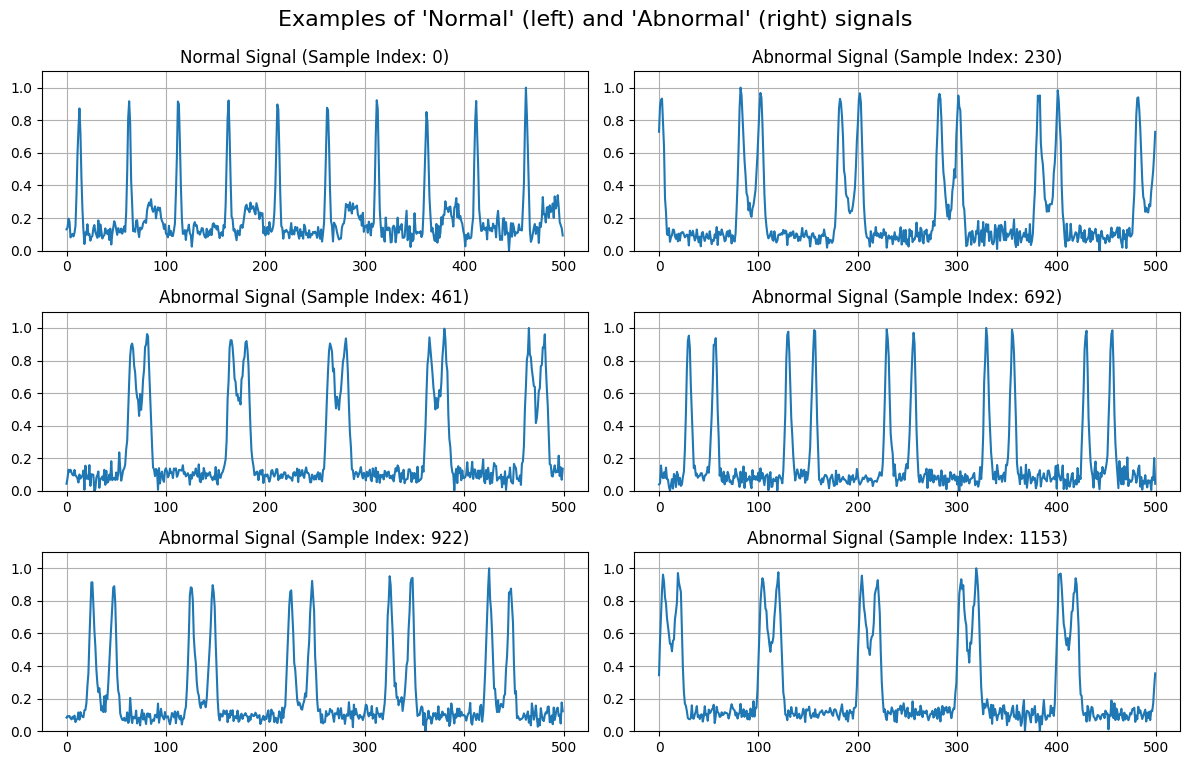

In [125]:
plt.figure(figsize=(12, 8)) # Adjusting the figure size

# Plotting 6 diverse signals
# We'll pick signals by spacing out the indices to get a representative view.
num_plots = 6
for i in range(num_plots):
    idx = (i * size_of_signal_dataset // num_plots) % size_of_signal_dataset
    signal, label = signal_dataset[idx]

    # Creates a subplot for the current signal
    plt.subplot(3, 2, i + 1) # 3 rows, 2 columns, current plot number (1-indexed)

    # Plots the signal. .numpy() is used to convert the PyTorch tensor to a NumPy array for matplotlib.
    plt.plot(signal.numpy())

    # Set the title based on the label
    title_label = "Normal" if label == 0 else "Abnormal"
    plt.title(f"{title_label} Signal (Sample Index: {idx})")

    # Set Y-axis limits consistently (assuming signals are normalized between 0 and 1)
    plt.ylim(0, 1.1)
    plt.grid(True) # Adds a grid for easier reading

# Adjust layout to prevent titles/labels from overlapping
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjusts rect to make space for suptitle

# Add a main title for the entire figure
plt.suptitle("Examples of 'Normal' (left) and 'Abnormal' (right) signals", fontsize=16)

# Display the plot
plt.show()

 (c) Split the original dataset into train-, validation- and test-sets. Choose some reasonable split
 values. You have to have enough data-points so that your network can learn as much and easily
 as possible while at the same time you also want enough data-points in your test set so that your
 estimate of the cost/accuracy on unseen data becomes as certain as possible. For example you may
 choose 70% for training, 20% for validation and 10% for test.

In [126]:
train_ratio = 0.7
val_ratio = 0.2
test_ratio = 0.1

train_size = int(train_ratio * size_of_signal_dataset)
val_size = int(val_ratio * size_of_signal_dataset)
test_size = size_of_signal_dataset - train_size - val_size # Ensure total sum equals dataset size

train_dataset, val_dataset, test_dataset = random_split(
    signal_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(42)
)

print(f"Train set size: {len(train_dataset)}")
print(f"Validation set size: {len(val_dataset)}")
print(f"Test set size: {len(test_dataset)}")

# Create DataLoaders for each spli t
batch_size = 64
train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False) # No shuffle for val/test
test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Train set size: 968
Validation set size: 276
Test set size: 140


(d): Choose a first preliminary FANN architecture that seems suitable for this 2-class classification
 task. You will not need more than two hidden layers with with ReLU activation functions in all
 hidden nodes. Make sure that your network has the correct number of inputs to the first linear layer
 and that it has 2 final output nodes in the last linear layer.

In [127]:
# Define the dimensions for the network layers
input_dim = signal_length  # This is the length of each signal (e.g., 500 features)
hidden_dim1 = 128          # Number of neurons in the first hidden layer
hidden_dim2 = 64           # Number of neurons in the second hidden layer
output_dim = 2             # Number of output classes: 0 (Normal), 1 (Abnormal)

# Create the FANN model using nn.Sequential
model = nn.Sequential(
    # Input layer to first hidden layer
    nn.Linear(input_dim, hidden_dim1), # Fully connected layer: input_dim - hidden_dim1 neurons
    nn.ReLU(),                         # Activation function for non-linearity

    # First hidden layer to second hidden layer
    nn.Linear(hidden_dim1, hidden_dim2), # Fully connected layer: hidden_dim1 - hidden_dim2 neurons
    nn.ReLU(),                         # Activation function for non-linearity

    # Second hidden layer to output layer
    # This final layer produces the raw scores (logits) for each of the 2 classes
    # NO nn.Softmax() here, as nn.CrossEntropyLoss will apply Softmax internally
    nn.Linear(hidden_dim2, output_dim)
)
print(model)

Sequential(
  (0): Linear(in_features=500, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=2, bias=True)
)


(e) Select and instantiate the loss function and the SGD optimizer with some suitable preliminary
 learning rate (the values 0.05 or 0.005 often work).

In [128]:
# 1. Loss Function:
# For multi-class (including 2-class) classification with raw logits (no Softmax in model output),
# nn.CrossEntropyLoss is the standard and correct choice in PyTorch.
# It internally applies Softmax to the model's raw outputs and then calculates the cross-entropy loss.
criterion = nn.CrossEntropyLoss()

# 2. Optimizer:
# I used Adam instead of Stochastic Gradient Descent (SGD)
# We need to pass the model's parameters to the optimizer so it knows what to update.
learning_rate = 0.05
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

print(f"Loss function instantiated: {criterion}")
print(f"Optimizer instantiated: {optimizer}")
print(f"Learning rate chosen: {learning_rate}")

Loss function instantiated: CrossEntropyLoss()
Optimizer instantiated: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.05
    maximize: False
    weight_decay: 0
)
Learning rate chosen: 0.05


(f) As afirst step, implement a very basic training loop consisting of only the mini-batch SGD inner-loop,
 without anything extra. Moreover, use only the set of training examples to check if you can get your
 model to reduce the cost/loss. This type of “test runs” of the training loop is always recommended as
 a sanity-check, to ensure that everything (model, batches and batch sizes) seem to work as expected.

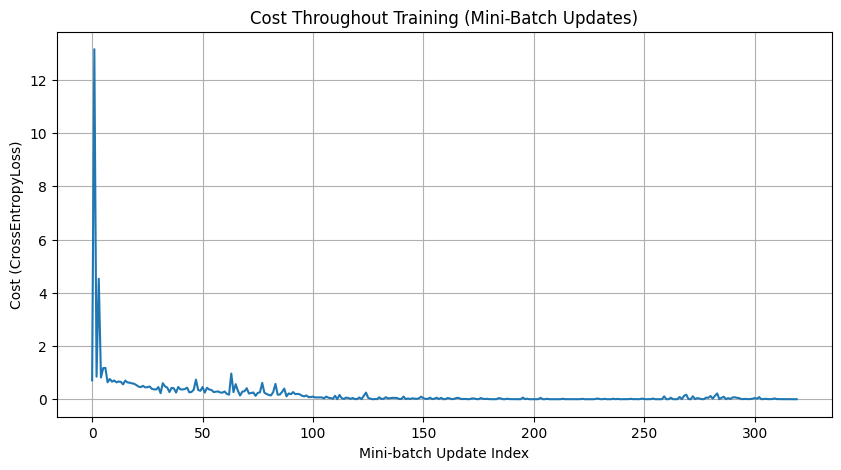

In [129]:
num_epochs = 20 # Run for a few epochs to see if loss goes down
mini_batch_losses = []      # To store loss after each mini-batch update


model.train() # Setting the model to training mode


for epoch in range(num_epochs):
    for i, (signals, labels) in enumerate(train_dataloader):

        signals = signals.float()
        # 1. Forward Pass: Compute model output for the current batch
        outputs = model(signals) # outputs are raw logits from the FANN

        # 2. Calculate Loss: Compare model outputs with true labels
        loss = criterion(outputs, labels) # CrossEntropyLoss expects raw logits and true labels

        # 3. Backward Pass: Compute gradients
        optimizer.zero_grad() # Clear previous gradients before computing new ones
        loss.backward()       # Compute gradients of the loss with respect to model parameters

        # 4. Optimizer Step: Update model parameters
        optimizer.step()      # Adjust model weights/biases based on computed gradients

        # Store the loss for plotting
        mini_batch_losses.append(loss.item()) # .item() gets the Python number from a single-element tensor

# Plotting mini-batch cost history
plt.figure(figsize=(10, 5))
plt.plot(mini_batch_losses)
plt.title("Cost Throughout Training (Mini-Batch Updates)")
plt.xlabel("Mini-batch Update Index")
plt.ylabel("Cost (CrossEntropyLoss)")
plt.grid(True)
plt.show()


(g) Define the function for model performance evaluation based on the template. Remember, this
 is classification task, and as such we should be interested in the accuracy of our model.

In [134]:
# Evaluates the classification accuracy of the model on a given dataset
def evaluate_model_accuracy(model, dataloader):
    model.eval()
    correct_predictions = 0
    total_samples = 0
    # Disable gradient calculations to save memory and speed up computation during evaluation
    with torch.no_grad():
        for signals, labels in dataloader:
            signals = signals.float()

            outputs = model(signals)
            predicted_labels = outputs.argmax(dim=1)

            total_samples += labels.size(0)
            correct_predictions += (predicted_labels == labels).sum().item()
    accuracy = (correct_predictions / total_samples) * 100
    model.train()
    return accuracy
print("Model evaluation function 'evaluate_model_accuracy' defined.")

print(f"\nAccuracy on training set: {evaluate_model_accuracy(model, train_dataloader):.2f}%")
print(f"Accuracy on validation set: {evaluate_model_accuracy(model, val_dataloader):.2f}%")
print(f"Accuracy on test set: {evaluate_model_accuracy(model, test_dataloader):.2f}%")


Model evaluation function 'evaluate_model_accuracy' defined.

Accuracy on training set: 100.00%
Accuracy on validation set: 98.55%
Accuracy on test set: 98.57%


**(h)** Integrate your model performance evaluation function into your training loop and perform model
 evaluation on both validation and train sets for every epoch, before the inner SGD training loop.
 Keep track and store these performance metrics during your whole training session, because you will
 need to plot and report these values for your fully trained network.

Number of signals in the dataset: 1384
Length of each signal (time points): 500
Train set: 968, Val set: 276, Test set: 140

FANN Architecture:
Sequential(
  (0): Linear(in_features=500, out_features=128, bias=True)
  (1): ReLU()
  (2): Linear(in_features=128, out_features=64, bias=True)
  (3): ReLU()
  (4): Linear(in_features=64, out_features=2, bias=True)
)

Loss function: CrossEntropyLoss(), Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.005
    maximize: False
    weight_decay: 0
), Learning rate: 0.005
Starting full training for 20 epochs...
Epoch:   0 | Train Cost: 0.680461 | Train Acc: 65.50% | Val Cost: 0.676617 | Val Acc: 68.12%
Epoch:   1 | Train Cost: 0.595487 | Train Acc: 65.50% | Val Cost: 0.567394 | Val Acc: 68.12%
Epoch:   2 | Train Cost: 0.430881 | Train Acc: 65.50% | Val Cost: 0.417084 | Val Acc: 68

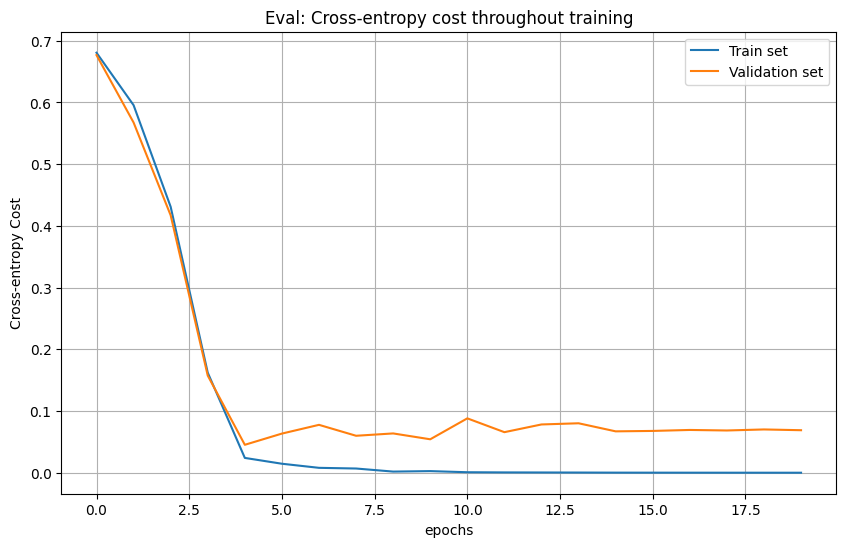

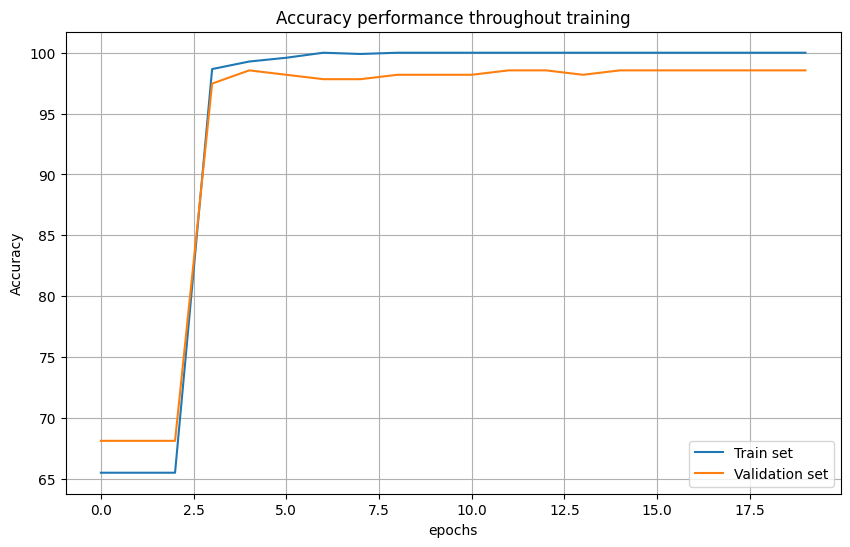


 Final Model Evaluation on Test Set
Final Test Set Accuracy: 98.57%
Final Test Set Cost: 0.0260


In [137]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt
import numpy as np
import help_code_ann_for_classification as help_code # Ensure this file is corrected and accessible

# Set a random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

# Loading the dataset and get dimensions
signal_dataset = help_code.SignalDataset()
size_of_signal_dataset = len(signal_dataset)
sample_signal, sample_label = signal_dataset[0]
signal_length = sample_signal.shape[0]
print(f"Number of signals in the dataset: {size_of_signal_dataset}")
print(f"Length of each signal (time points): {signal_length}")

# Splitting dataset and create DataLoaders
train_ratio = 0.70
val_ratio = 0.20
test_ratio = 0.10
train_size = int(train_ratio * size_of_signal_dataset)
val_size = int(val_ratio * size_of_signal_dataset)
test_size = size_of_signal_dataset - train_size - val_size
train_dataset, val_dataset, test_dataset = random_split(
    signal_dataset, [train_size, val_size, test_size], generator=torch.Generator().manual_seed(42)
)
print(f"Train set: {len(train_dataset)}, Val set: {len(val_dataset)}, Test set: {len(test_dataset)}")
batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# FANN Architecture
input_dim = signal_length
hidden_dim1 = 128
hidden_dim2 = 64
output_dim = 2
model = nn.Sequential(
    nn.Linear(input_dim, hidden_dim1),
    nn.ReLU(),
    nn.Linear(hidden_dim1, hidden_dim2),
    nn.ReLU(),
    nn.Linear(hidden_dim2, output_dim)
)
print("\nFANN Architecture:")
print(model)

# Loss Function and Optimizer
criterion = nn.CrossEntropyLoss()
learning_rate = 0.005
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
print(f"\nLoss function: {criterion}, Optimizer: {optimizer}, Learning rate: {learning_rate}")

# Model Performance Evaluation Function
def evaluate_model_accuracy(model, dataloader):
    model.eval()
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad():
        for signals, labels in dataloader:
            signals = signals.float()
            outputs = model(signals)
            predicted_labels = outputs.argmax(dim=1)
            total_samples += labels.size(0)
            correct_predictions += (predicted_labels == labels).sum().item()
    accuracy = (correct_predictions / total_samples) * 100
    model.train()
    return accuracy

# Function to evaluate average Cross-Entropy Cost
def evaluate_model_cost(model, dataloader, criterion):
    model.eval()
    total_cost = 0.0
    total_samples = 0
    with torch.no_grad():
        for signals, labels in dataloader:
            signals = signals.float()
            outputs = model(signals)
            loss = criterion(outputs, labels)
            total_cost += loss.item() * labels.size(0) # Multiply by batch size for weighted average
            total_samples += labels.size(0)
    avg_cost = total_cost / total_samples
    model.train()
    return avg_cost

# Full Training Loop with Evaluation


num_epochs = 20 # Increased epochs for full training and convergence observation

# Lists to store performance metrics over epochs
train_costs = []
val_costs = []
train_accuracies = []
val_accuracies = []

print(f"Starting full training for {num_epochs} epochs...")
for epoch in range(num_epochs):
    # Evaluate costs
    current_train_cost = evaluate_model_cost(model, train_loader, criterion)
    current_val_cost = evaluate_model_cost(model, val_loader, criterion)
    train_costs.append(current_train_cost)
    val_costs.append(current_val_cost)

    # Evaluate accuracies
    current_train_acc = evaluate_model_accuracy(model, train_loader)
    current_val_acc = evaluate_model_accuracy(model, val_loader)
    train_accuracies.append(current_train_acc)
    val_accuracies.append(current_val_acc)

    # Print performance metrics
    print(f"Epoch: {epoch:3d} | "
          f"Train Cost: {current_train_cost:.6f} | Train Acc: {current_train_acc:.2f}% | "
          f"Val Cost: {current_val_cost:.6f} | Val Acc: {current_val_acc:.2f}%")

    # Inner SGD Training Loop
    model.train() # Ensure model is in training mode for parameter updates
    for signals, labels in train_loader:
        signals = signals.float() # Ensure input type is float

        # Forward pass
        outputs = model(signals)
        loss = criterion(outputs, labels)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

print("\nFull training loop completed. Stored metrics for plotting.")


# Plotting Cross-Entropy Cost (Figure 7)
plt.figure(figsize=(10, 6))
plt.plot(train_costs, label="Train set")
plt.plot(val_costs, label="Validation set")
plt.title("Eval: Cross-entropy cost throughout training")
plt.xlabel("epochs")
plt.ylabel("Cross-entropy Cost")
plt.legend()
plt.grid(True)
plt.show()

# Plotting Accuracy Performance (Figure 8)
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label="Train set")
plt.plot(val_accuracies, label="Validation set")
plt.title("Accuracy performance throughout training")
plt.xlabel("epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()



# Final Test Set Evaluation
print("\n Final Model Evaluation on Test Set")
final_test_accuracy = evaluate_model_accuracy(model, test_loader)
final_test_cost = evaluate_model_cost(model, test_loader, criterion)
print(f"Final Test Set Accuracy: {final_test_accuracy:.2f}%")
print(f"Final Test Set Cost: {final_test_cost:.4f}")

**Task B**

(a) Repeat the procedure you performed when designing and testing the signal classifiers in Task
 A, this time using the FashionMNIST dataset. The main difference here:
 1. Images that need to be flattened into vectors (each having28 · 28 = 784 elements) before they
 can be presented to the FANN. How we deal with this is by placing a nn.Flatten() component
 at the beginning of our architecture specification in nn.Sequential(...). Tip: See “But what
 is a neural network? — Chapter 1, Deep learning” from 3Blue1Brown provided in the Extra
 materials at the end of this document.
 2. A 10-class problem instead of a 2-class problem.

(b) Determine and print out the accuracy of the final FANN classifier based on the examples in the independent test set.

100%|██████████| 26.4M/26.4M [00:01<00:00, 15.0MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 268kB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 5.03MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 12.8MB/s]


Total training data samples: 60000
Total test data samples: 10000
Image shape: torch.Size([1, 28, 28])
Flattened input dimension for FANN: 784
Number of classes: 10
Actual Train set size: 48000
Actual Validation set size: 12000
Train DataLoader has 750 batches.
Validation DataLoader has 188 batches.
Test DataLoader has 157 batches.
Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): ReLU()
  (3): Linear(in_features=256, out_features=128, bias=True)
  (4): ReLU()
  (5): Linear(in_features=128, out_features=10, bias=True)
)
Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.005
    maximize: False
    weight_decay: 0
)
Learning rate: 0.005
Evaluation functions 'evaluate_model_accuracy' and 'evaluate_model_cost' defined.
Ep

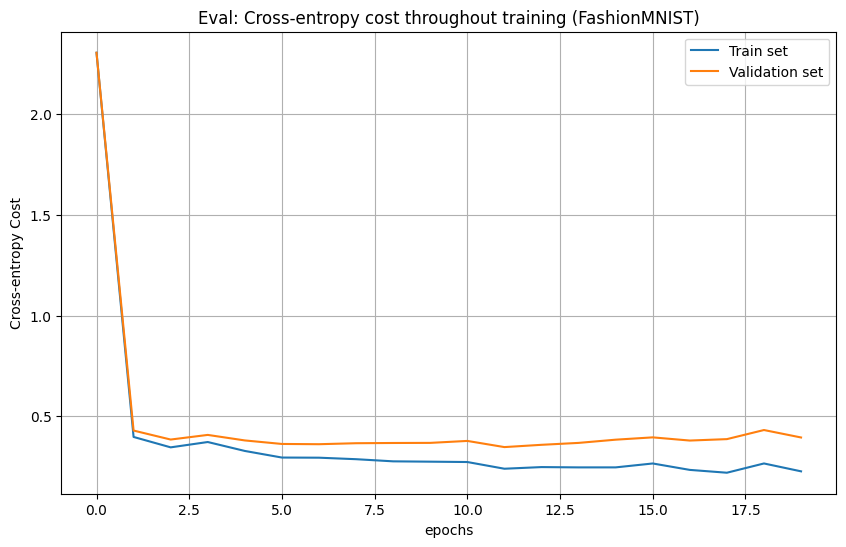

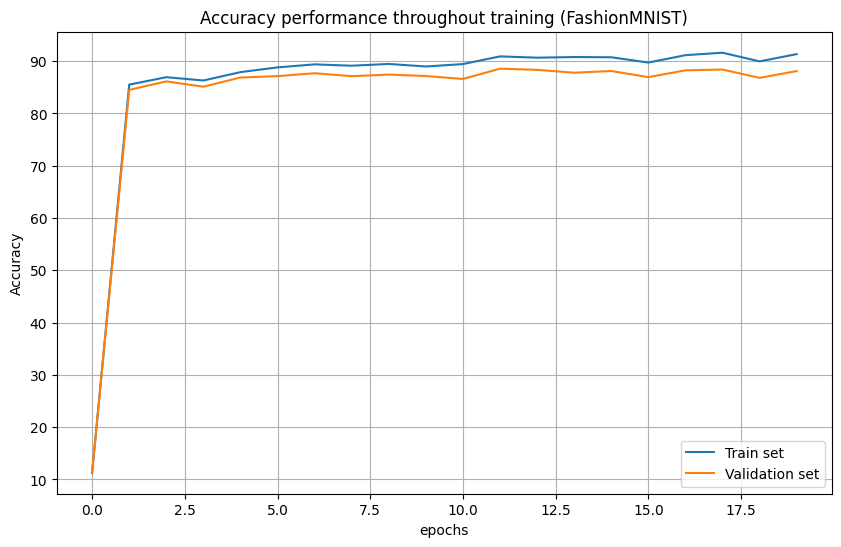

Final Test Set Accuracy: 87.11%
Final Test Set Cost: 0.4281


In [2]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, TensorDataset
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

# Setting a random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)


# Problem 4.4 (a) Solution: Repeat Task A Procedure with FashionMNIST

# 1. LOAD FASHIONMNIST DATASET
# Define transformations: Convert image to PyTorch tensor
transform_pipeline = transforms.Compose([
    transforms.ToTensor(), # Converts PIL Image to PyTorch Tensor (HWC to CHW, 0-255 to 0.0-1.0)
])

# Download training data from open datasets.
full_train_data = datasets.FashionMNIST(
    root="data",         # Directory to store the dataset
    train=True,          # Specify this is the training part of the dataset
    download=True,       # Download if not already present
    transform=transform_pipeline, # Apply the defined transformations
)

# Download test data from open datasets.
test_dataset = datasets.FashionMNIST(
    root="data",
    train=False,         # Specify this is the test part of the dataset
    download=True,
    transform=transform_pipeline,
)

print(f"Total training data samples: {len(full_train_data)}")
print(f"Total test data samples: {len(test_dataset)}")

# Inspect one image to get dimensions
sample_image, sample_label = full_train_data[0]
image_shape = sample_image.shape # e.g., torch.Size([1, 28, 28])
image_height, image_width = image_shape[1], image_shape[2]
input_dim_flattened = image_height * image_width # 28 * 28 = 784
num_classes = 10 # FashionMNIST has 10 classes

print(f"Image shape: {image_shape}")
print(f"Flattened input dimension for FANN: {input_dim_flattened}")
print(f"Number of classes: {num_classes}")


# 2. TRAIN/VALIDATION SPLIT from the full_train_data

train_ratio = 0.8 # Use 80% of full_train_data for actual training
val_ratio = 0.2   # Use 20% of full_train_data for validation

train_size = int(train_ratio * len(full_train_data))
val_size = len(full_train_data) - train_size

train_dataset, val_dataset = random_split(
    full_train_data, [train_size, val_size], generator=torch.Generator().manual_seed(42)
)

print(f"Actual Train set size: {len(train_dataset)}")
print(f"Actual Validation set size: {len(val_dataset)}")



# 3. CREATE DATALOADERS

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False) # Use test_dataset directly

print(f"Train DataLoader has {len(train_loader)} batches.")
print(f"Validation DataLoader has {len(val_loader)} batches.")
print(f"Test DataLoader has {len(test_loader)} batches.")


# 4. CREATE FANN MODEL (Multi-class Image)
hidden_dim1 = 256
hidden_dim2 = 128
# output_dim is already set to num_classes = 10

model = nn.Sequential(
    nn.Flatten(),                     # Flattens the 2D image (1x28x28) into a 1D vector (784)
    nn.Linear(input_dim_flattened, hidden_dim1), # Input (784) to 1st hidden layer (256)
    nn.ReLU(),
    nn.Linear(hidden_dim1, hidden_dim2),         # 1st hidden (256) to 2nd hidden layer (128)
    nn.ReLU(),
    nn.Linear(hidden_dim2, num_classes)          # 2nd hidden (128) to Output layer (10 classes)
)
print(model)



# 5. LOSS FUNCTION AND OPTIMIZER

criterion = nn.CrossEntropyLoss() # Standard for multi-class classification (includes Softmax)
learning_rate = 0.005
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate) # I used Adam here as an optimizer

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Learning rate:", learning_rate)



# 6. DEFINE EVALUATION FUNCTIONS (reusing from Task A)

def evaluate_model_accuracy(model, dataloader):
    model.eval()
    correct_predictions = 0
    total_samples = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.view(images.size(0), -1) # Ensure images are flattened if not already
                                                     # (DataLoader for FashionMNIST gives [batch, 1, H, W])
            outputs = model(images)
            predicted_labels = outputs.argmax(dim=1)
            total_samples += labels.size(0)
            correct_predictions += (predicted_labels == labels).sum().item()
    accuracy = (correct_predictions / total_samples) * 100
    model.train()
    return accuracy

def evaluate_model_cost(model, dataloader, criterion):
    model.eval()
    total_cost = 0.0
    total_samples = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.view(images.size(0), -1) # Flatten images
            outputs = model(images)
            loss = criterion(outputs, labels)
            total_cost += loss.item() * labels.size(0)
            total_samples += labels.size(0)
    avg_cost = total_cost / total_samples
    model.train()
    return avg_cost

print("Evaluation functions 'evaluate_model_accuracy' and 'evaluate_model_cost' defined.")



# 7. FULL TRAINING LOOP WITH EVALUATION

num_epochs = 20 # Train for a reasonable number of epochs

train_costs = []
val_costs = []
train_accuracies = []
val_accuracies = []

for epoch in range(num_epochs):
    # Evaluate Model Performance (before training the epoch)
    current_train_cost = evaluate_model_cost(model, train_loader, criterion)
    current_val_cost = evaluate_model_cost(model, val_loader, criterion)
    train_costs.append(current_train_cost)
    val_costs.append(current_val_cost)

    current_train_acc = evaluate_model_accuracy(model, train_loader)
    current_val_acc = evaluate_model_accuracy(model, val_loader)
    train_accuracies.append(current_train_acc)
    val_accuracies.append(current_val_acc)

    # Print performance metrics
    print(f"Epoch: {epoch:3d} | "
          f"Train Cost: {current_train_cost:.6f} | Train Acc: {current_train_acc:.2f}% | "
          f"Val Cost: {current_val_cost:.6f} | Val Acc: {current_val_acc:.2f}%")

    # Inner Training Loop
    model.train() # Ensure model is in training mode
    for images, labels in train_loader:

       images = images.float()

       # Forward pass
       outputs = model(images)
       loss = criterion(outputs, labels)

       # Backward and optimize
       optimizer.zero_grad()
       loss.backward()
       optimizer.step()

print("\nFull training loop completed. Stored metrics for plotting.")



# 8. PLOT PERFORMANCE METRICS

# Plotting Cross-Entropy Cost
plt.figure(figsize=(10, 6))
plt.plot(train_costs, label="Train set")
plt.plot(val_costs, label="Validation set")
plt.title("Eval: Cross-entropy cost throughout training (FashionMNIST)")
plt.xlabel("epochs")
plt.ylabel("Cross-entropy Cost")
plt.legend()
plt.grid(True)
plt.show()

# Plotting Accuracy Performance
plt.figure(figsize=(10, 6))
plt.plot(train_accuracies, label="Train set")
plt.plot(val_accuracies, label="Validation set")
plt.title("Accuracy performance throughout training (FashionMNIST)")
plt.xlabel("epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Problem 4.4 (b) Solution: Test Set Accuracy

final_test_accuracy = evaluate_model_accuracy(model, test_loader)
final_test_cost = evaluate_model_cost(model, test_loader, criterion)
print(f"Final Test Set Accuracy: {final_test_accuracy:.2f}%")
print(f"Final Test Set Cost: {final_test_cost:.4f}")


**Potential Applications of Image Classification**


1. Healthcare and Medical Diagnostics:

**Application:** Image classification is revolutionizing medical diagnostics by assisting in the analysis of various medical images. For instance, models can be trained to classify X-rays for pneumonia detection, MRI scans for tumor identification (e.g., brain tumors), retinal scans for diabetic retinopathy screening, or pathology slides for cancer grading. The "kind" of image classification here involves distinguishing between healthy and diseased states, or classifying the type/severity of a condition.

**Practical and Commercial Importance:**
- Early and Accurate Diagnosis: Helps medical professionals (radiologists, pathologists) in making faster and more accurate diagnoses, potentially leading to earlier intervention and better patient outcomes.
- Reduced Workload/Cost: Automates initial screening tasks, reducing the immense workload on human experts and lowering healthcare costs.
- Accessibility: Can be deployed in remote areas where specialized medical expertise is scarce, making advanced diagnostics more accessible.
- Drug Discovery & Research: Accelerates research by automating the analysis of cellular or tissue images in laboratories.

2. Industrial Quality Control and Manufacturing Inspection:

**Application:** In various manufacturing sectors (automotive, electronics, food processing, etc.), image classification is extensively used for automated quality inspection. For example, it can classify images of manufactured parts (e.g., circuit boards, car components, food items) to detect defects (cracks, scratches, missing components, discoloration), ensuring only high-quality products proceed. The "kind" of image classification here involves identifying "good" vs. "defective" items, or categorizing specific types of defects.

**Practical and Commercial Importance:**

- Increased Efficiency: Replaces slow, inconsistent, and error-prone manual inspection with high-speed, objective, and consistent automated checks.
- Cost Reduction: Minimizes waste due to detected defects early in the production line, reduces rework, and prevents defective products from reaching customers, which saves warranty and recall costs.
- Improved Product Quality: Ensures consistent product quality and adherence to specifications, enhancing brand reputation and customer satisfaction.
- Scalability: Can be easily scaled to inspect millions of items per day in high-volume production environments.

**Task C: Convolutional ANNs**

Problem 1: CNN Theory

Consider a single CNN features map produced directly from an input image. Assume that the size
 of the kernel is m × m. This corresponds to each neuron having a receptive field that is limited to
 a m×m part of the input image.

**(a)** How many adjustable parameters does the feature map corresponding to this kernel have?

For a single kernel of size m x m, the number of adjustable parameters is simply the number of values in that kernel.

- Number of Adjustable Parameters = m * m (for the weights of the kernel)

Additionally, each feature map also typically has one bias parameter associated with it, which is added to the output of the convolution before the activation function. This bias allows the activation function to shift its output.

- Therefore, the total number of adjustable parameters for a single feature map produced by an m x m kernel is m * m + 1.

 **(b)** Assume your CNN has 2 feature maps produced directly from the input image, all with kernel
 size m × m. How many adjustable parameters are there in this case? Why does the number of
 adjustable parameters not depend on the size of the input image?

- If there are 2 feature maps, and each is produced by a unique m x m kernel (plus its bias), then the total number of adjustable parameters is:

- Total Adjustable Parameters = 2 * (m * m + 1)

A convolutional kernel is a small matrix of weights that slides across the entire input image. The same kernel (with the same values) is used at every spatial location where it's applied.

Since the kernel's weights are reused across the image, their number is fixed by the kernel's dimensions (m x m) and the number of feature maps, not by the potentially much larger dimensions of the input image itself. This is a huge advantage over fully connected layers for image processing.


**(c)** Assume you have small images of size 28×28 pixels. What is are reasonable sizes of the kernel
 used in a CNN that should process this image? In particular, why is for example the kernel size
 27 ×27 unreasonable large here?

 Typically, convolutional kernels are small for practical reasons and to allow the network to learn local features efficiently.
Common kernel sizes include 3x3, 5x5, or sometimes 7x7.
A 3x3 kernel is very popular as it's small enough to capture fine details but can also be stacked to build larger receptive fields (as seen in deeper CNNs).

Why a kernel size of 27x27 is unreasonably large here:

An input image is 28x28 pixels.
A 27x27 kernel is almost as large as the entire image.
If we use a 27x27 kernel, that single kernel would essentially look at almost the entire image at once (a very large receptive field from the start).

This defeats the purpose of convolutions' local receptive fields and hierarchical feature learning.

The idea is to first detect small, local features (like tiny edges or corners) and then combine them in subsequent layers into more complex patterns. A 27x27 kernel tries to learn a very complex pattern directly from raw pixels, which is inefficient.

**Problem 2: Image Classification using a CNN**

(a) Run the following code as a whole or in parts. Make sure you can explain what it does on each row.

In [4]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

# Define the CNN model
class Net(nn.Module):           # Defines a new neural network class named 'nets' that inherits from nn.Module
    def __init__(self):
        super(Net, self).__init__()  # Calls the constructor of the parent class
        self.conv1 = nn.Conv2d(1, 32, 3)  # Defines the first 2D convolutional layer using a 3x3 kernel
        self.pool = nn.MaxPool2d(2, 2)    # Defines a max pooling layer with kernel size 2 (2x2) and stride value 2
        self.conv2 = nn.Conv2d(32, 64, 3) # Defines the second 2D convolutional layer using a 3x3 kernel
        self.fc1 = nn.Linear(64 * 5 * 5, 128) # Defines the first fully connected (linear) layer
        self.fc2 = nn.Linear(128, 10)         # Defines the second fully connected (linear) layer

    def forward(self, x):                         # Defines the forward pass of the network
        x = self.pool(torch.relu(self.conv1(x)))  # Input x goes through the first convolutional layer
        x = self.pool(torch.relu(self.conv2(x)))  # The output from the first convolutional layer goes through the second conv layer, ReLU, and Max Pooling
        # x.view: flattens the output of the convolutional layers into a 1D vector for the fully connected layers
        x = x.view(-1, 64 * 5 * 5) # PyTorch’s equivalent to numpy.reshape()
        # The flattened features go through the first fully connected layer, followed by a ReLU activation
        x = torch.relu(self.fc1(x))
        # The output from fc1 goes through the final fully connected layer
        # This produces the raw logits for the 10 classes
        x = self.fc2(x) # No softmax at the end although classifciation
        return x        # Returns the raw logits as the network's final output

# Initialize the model
net = Net()       # Creates an instance of the Net class, initializing the CNN model

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()    # Defines the Cross Entropy Loss function, suitable for multi-class classification with raw logits
optimizer = optim.Adam(net.parameters(), lr=0.001) # Defines the Adam optimizer, which will update the model's parameters during training

# Load and preprocess the FashionMNIST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))]) # Defines the transformation pipeline for the images
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform) # Downloads/loads the FashionMNIST training set, applies the transformations
trainloader = torch.utils.data.DataLoader(trainset, batch_size=64, shuffle=True)    # Creates a DataLoader for the training set, with batches of 64 samples, shuffled

# Training loop
for epoch in range(10): # Change the number of epochs as needed
#Starts the main training loop, iterating over a specified number of epochs
    running_loss = 0.0  # Initializes a variable to accumulate loss over mini-batches for periodic printing
    for i, data in enumerate(trainloader, 0): # Inner loop: Iterates through mini-batches provided by the trainloader
        inputs, labels = data   # Inner loop: Iterates through mini-batches provided by the trainloader

        optimizer.zero_grad()   # Clears old gradients from the previous optimization step

        outputs = net(inputs)   # Performs the forward pass: inputs are fed into the CNN to get raw logits
        loss = criterion(outputs, labels) # Calculates the loss by comparing model outputs (logits) with true labels
        loss.backward()   # Performs the backward pass: computes gradients of the loss w.r.t. model parameters
        optimizer.step()  # Updates the model's parameters using the gradients and learning rate

        running_loss += loss.item()
        if i % 100 == 99: # Print every 100 mini-batches
            print(f'[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 100:.3f}')
            running_loss = 0.0

print('Finished Training')

# Save the parameters of the trained model
torch.save(net.state_dict(), 'fashion_mnist_cnn.pth')

[Epoch 1, Batch 100] Loss: 0.912
[Epoch 1, Batch 200] Loss: 0.563
[Epoch 1, Batch 300] Loss: 0.491
[Epoch 1, Batch 400] Loss: 0.452
[Epoch 1, Batch 500] Loss: 0.420
[Epoch 1, Batch 600] Loss: 0.409
[Epoch 1, Batch 700] Loss: 0.378
[Epoch 1, Batch 800] Loss: 0.365
[Epoch 1, Batch 900] Loss: 0.371
[Epoch 2, Batch 100] Loss: 0.341
[Epoch 2, Batch 200] Loss: 0.326
[Epoch 2, Batch 300] Loss: 0.326
[Epoch 2, Batch 400] Loss: 0.316
[Epoch 2, Batch 500] Loss: 0.321
[Epoch 2, Batch 600] Loss: 0.324
[Epoch 2, Batch 700] Loss: 0.320
[Epoch 2, Batch 800] Loss: 0.292
[Epoch 2, Batch 900] Loss: 0.296
[Epoch 3, Batch 100] Loss: 0.278
[Epoch 3, Batch 200] Loss: 0.269
[Epoch 3, Batch 300] Loss: 0.266
[Epoch 3, Batch 400] Loss: 0.271
[Epoch 3, Batch 500] Loss: 0.265
[Epoch 3, Batch 600] Loss: 0.271
[Epoch 3, Batch 700] Loss: 0.278
[Epoch 3, Batch 800] Loss: 0.279
[Epoch 3, Batch 900] Loss: 0.260
[Epoch 4, Batch 100] Loss: 0.223
[Epoch 4, Batch 200] Loss: 0.240
[Epoch 4, Batch 300] Loss: 0.241
[Epoch 4, 

(b) What is the size of the kernel (filter) in the first layer of the CNN implemented by this code?

self.conv1 = nn.Conv2d(1, 32, 3)

The third argument, 3, specifies the kernel_size. The kernel size in the first layer (conv1) is 3x3.

(c)Explain by means of words, numbers, or pictures what is the structure of the CNN implemented
 by this code?

The CNN implemented by this code (Net class) has the following structure:
1. Input Layer:

- Receives grayscale images of size 1x28x28 (1 channel, 28 height, 28 width).
2. First Convolutional Block:

- self.conv1 = nn.Conv2d(1, 32, kernel_size=3):
  - Takes the 1x28x28 input.
  - Applies 32 filters, each of size 3x3.
  - Output feature map size (assuming no padding for simplicity in calculation): 1x(28-3+1)x(28-3+1) = 32x26x26.
- torch.relu(...): A ReLU activation is applied element-wise.
- self.pool = nn.MaxPool2d(2, stride=2):
  - Applies a 2x2 max-pooling operation with a stride of 2.
  - This halves the spatial dimensions.
  - Output size: 32x(26/2)x(26/2) = 32x13x13.
3. Second Convolutional Block:
- self.conv2 = nn.Conv2d(32, 64, kernel_size=3):
  - Takes the 32x13x13 feature maps from the previous pooling layer.
  - Applies 64 filters, each of size 3x3.
  - Output feature map size: 64x(13-3+1)x(13-3+1) = 64x11x11.
- torch.relu(...): A ReLU activation is applied element-wise.
- self.pool = nn.MaxPool2d(2, stride=2):
  - Applies another 2x2 max-pooling operation with a stride of 2.
  - Output size: 64x(11/2)x(11/2) = 64x5x5 (due to integer division, 11/2 becomes 5).
4. Flattening Layer:
- x.view(-1, 64 * 5 * 5):
  - The 64x5x5 multi-dimensional tensor is flattened into a single 1D vector for each image in the batch.
  - Size: 64 * 5 * 5 = 1600 features per image.
5. First Fully Connected Layer:
- self.fc1 = nn.Linear(1600, 128):
  - Takes 1600 flattened features as input.
  - Transforms them into 128 outputs.
- torch.relu(...): A ReLU activation is applied element-wise.
6. Output Fully Connected Layer:
- self.fc2 = nn.Linear(128, 10):
  - Takes 128 inputs from the previous layer.
  - Produces 10 raw output scores (logits), one for each of the 10 FashionMNIST classes.
  - No Softmax is applied in the model itself, as nn.CrossEntropyLoss will handle it during loss calculation.

 (e) After completing the training above, run the following code to determine the accuracy (proba
bility of correct classifications) of the final trained classifier on the training set itself. What is the
 loss/costfunctionusedhere,and why is not probability of missclassification used as a cost function instead?

In [6]:
#Perform the testing batchwise
correct_train= 0
total_train = 0
with torch.no_grad():
    for images, labels in trainloader:
        outputs = net(images)
        predicted_values, predicted_indicies = torch.max(outputs.data, 1)
        total_train+= labels.size(0)
        correct_train += (predicted_indicies == labels).sum().item()

#Calculate Accuracy
accuracy_train = 100 * correct_train / total_train
print(f'Accuracy on the train dataset: {accuracy_train:.2f}%')
print("No of training examples:", total_train)

Accuracy on the train dataset: 96.71%
No of training examples: 60000


What is the loss/cost function used here?

- The loss/cost function used during the training of this CNN is nn.CrossEntropyLoss().

Why is not probability of misclassification used as a cost function instead?

Probability of Misclassification (Error Rate): This metric (calculated as 1 - Accuracy) is a valid performance metric to report and understand how well the model classifies. However, it is not suitable for directly training neural networks via gradient-based optimization.
- Reasons why error count (or probability of misclassification) is not used as a cost function for training:
1. Non-Differentiability: The error count is a discrete, step-wise function. A tiny change in a network's weight rarely changes the number of misclassifications; it only changes if the prediction flips from wrong to right, or vice-versa. This means the gradient of this function is effectively zero almost everywhere, or undefined at the few points where a flip occurs. Optimization algorithms like Stochastic Gradient Descent (SGD) or Adam rely on continuous, well-defined gradients to know how to adjust parameters. Without these gradients, the optimizer gets no meaningful signal to learn.

2. Lack of Sensitivity to "How Wrong": This metric only tells you if a prediction is correct or incorrect, not how confident the model was, or how close it was to being correct.
- Consider two incorrect predictions: one where the model was barely wrong (e.g., true class 1, predicted class 0 with 51% probability) and another where it was extremely wrong (e.g., true class 1, predicted class 0 with 99% probability). The error rate treats both as just "1 error."
- nn.CrossEntropyLoss(), however, assigns a much higher penalty to the prediction where the model was very confident in the wrong answer, providing a stronger "error signal" that helps the network adjust its weights more effectively. This allows the network to learn not just to be right, but to be confidently right.

3. Plateaus in the Search Space: The loss landscape created by error count would be very "flat" between the "steps," with no smooth slopes to guide the optimizer towards better solutions.


**Cross-Entropy's Advantage:** nn.CrossEntropyLoss() is continuous and differentiable across the entire range of predictions, providing smooth and informative gradients. This allows gradient-based optimizers to efficiently and effectively guide the model parameters towards a solution that minimizes classification errors.

**Problem 3: Performance Estimation of a CNN**

**(a)** After completing the above problems, estimate the true performance of your trained CNN classifier by using the following code. It imports the saved weights of a trained CNN and tests it on the examples in the independent test set.

In [8]:
loaded_model = Net() #initializa the model
loaded_model.load_state_dict(torch.load('fashion_mnist_cnn.pth'))
loaded_model.eval() #Put it in evaluation mode

# Load and preprocess the FashionMNIST TEST dataset
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.5,), (0.5,))])
test_dataset = torchvision.datasets.FashionMNIST(root='./data', train=False, transform=transform, download=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

#Perform the testing batchwise
correct_test = 0
total_test = 0
with torch.no_grad():
    for images, labels in test_loader:
        outputs = loaded_model(images)
        predicted_values, predicted_indicies = torch.max(outputs.data, 1)
        total_test += labels.size(0)
        correct_test += (predicted_indicies == labels).sum().item()

#Calculate Accuracy
accuracy_test = 100 * correct_test / total_test
print(f'Accuracy on the test dataset: {accuracy_test:.2f}%')
print("No of testexamples:", total_test)

Accuracy on the test dataset: 91.50%
No of testexamples: 10000


**(b)** Make a comparison - any big difference between the accuracy estimates obtained with the test and training sets? What is your interpretation of this result in terms of overfitting?

There is a difference of 96.71% - 91.50% = 5.21% between the training accuracy and the test accuracy.

This difference of 5.21% indicates that there is a noticeable degree of overfitting.
- The model has achieved a very high accuracy (almost 97%) on the training data, suggesting it has learned the patterns in the training set extremely well.
- However, its performance drops by more than 5 percentage points when evaluated on the independent test set (unseen data). This drop signifies that the model has started to memorize some specific characteristics or noise present in the training data that are not generalizable to new, unseen examples. If the model had generalized perfectly, the test accuracy would be much closer to the training accuracy.


While 91.50% on the test set is still a strong result for a CNN on FashionMNIST, the gap clearly points to overfitting.

**(c)** Compare your accuracy on the external test set obtained here with the corresponding accuracy obtained using the FANN studied earlier using the same test set. Which of the networks seems to perform best?


- CNN Test Set Accuracy: 91.50%
- FANN Test Set Accuracy: 87.11%


Comparing the two, the CNN achieved a test set accuracy of 91.50%, which is 4.39 percentage points higher than the FANN's 87.11%.

The Convolutional Neural Network (CNN) performs best for the FashionMNIST image classification task.


This result strongly supports the widely observed advantage of CNNs over FANNs (Multi-layer Perceptrons) for tasks involving image data. The key reasons for the CNN's superior performance are:

1. Preservation of Spatial Information: CNNs utilize convolutional layers that operate on the 2D (or 3D for color) structure of images. This allows them to inherently learn and preserve spatial relationships and local patterns (like edges, textures, and shapes). A FANN, by requiring images to be flattened into a 1D vector, completely loses this valuable spatial context, making it much harder to extract meaningful visual features.
2. Hierarchical Feature Learning: CNNs are designed to learn features in a hierarchical manner. Early layers detect simple, low-level features, which are then combined by deeper layers to form more complex, abstract representations. This mirrors how the human visual system works.
3. Parameter Efficiency (Parameter Sharing): In CNNs, the same set of weights (a kernel/filter) is reused across different spatial locations in the input (parameter sharing). This drastically reduces the total number of trainable parameters compared to a FANN (where each neuron in one layer is connected to every neuron in the previous layer). Fewer parameters lead to more efficient learning, less memory usage, and a reduced risk of overfitting for the same model capacity.

The higher accuracy of the CNN on the independent test set demonstrates its greater ability to generalize and correctly classify unseen clothing items, making it the more effective network for this kind of image classification problem.
